In [2]:
from CNN_model_helper import (evaluate_fold_TL, set_freeze_mode_cnn, plot_training_progress, find_optimal_clusters)
from pathlib import Path
import sys
import pandas as pd
from sklearn.model_selection import StratifiedKFold
import numpy as np
from CNN_model import CNNRegressor 

In [3]:
data_prefix_MW = '../MW/artifacts_threshold/'

df = pd.read_parquet(data_prefix_MW + "scaled_final_dataset_RDKit_60(split)_MW(label)_70(threshold).parquet")
df.head()

,SMILES,MP,Type,MW_label,RDKit_fr_NH1,RDKit_VSA_EState7,RDKit_EState_VSA8,RDKit_VSA_EState9,RDKit_SlogP_VSA4,RDKit_fr_pyridine,...,RDKit_RingCount,RDKit_FpDensityMorgan2,RDKit_SPS,RDKit_fr_ester,RDKit_VSA_EState1,RDKit_SMR_VSA6,RDKit_fr_bicyclic,RDKit_SMR_VSA5,RDKit_NumAtomStereoCenters,RDKit_PEOE_VSA9
0,O=Cc1ccccc1OC(=O)C,38.0,Train,0,-0.463609,-0.191767,-0.680559,-0.154896,-0.65812,-0.266204,...,-0.673751,0.832282,-0.604616,1.449116,-0.194700,-0.677532,-0.462140,-0.440317,-0.364053,-0.327314
1,CCOC(=O)Nc1ccc2c(c1)nn(n2)C1CCCC1,121.5,Train,0,1.305228,0.542864,0.131266,-0.154896,-0.65812,-0.266204,...,0.857023,0.870914,0.051270,-0.333509,-0.190130,0.636993,0.335393,0.689560,-0.364053,0.483141
2,O1CC1COc1cccc(c1)OCC1OC1,34.0,Train,0,-0.463609,-0.209136,-0.680559,-0.154896,-0.65812,-0.266204,...,0.857023,-0.519820,1.110011,-0.333509,0.671746,2.235970,-0.462140,-0.252123,0.687644,0.547773
3,CCCCCCCCCCCCCCCC(=O)O.N,22.0,Train,0,-0.463609,3.115121,-0.318254,-0.154896,-0.65812,-0.266204,...,-1.439138,-1.678766,-0.497288,-0.333509,-0.445016,-0.677532,-0.462140,2.761131,-0.364053,-0.963694
4,CC(=O)Oc1ccc(c(c1)C)OC(=O)C,41.0,Train,0,-0.463609,-0.321321,-0.680559,-0.154896,0.04661,-0.266204,...,-0.673751,-0.133505,-0.559669,3.231740,0.069747,-0.677532,-0.462140,0.052855,-0.364053,-0.963694


In [4]:
df_highMW = df[
    (df["Type"] == "Train") &
    (df["MW_label"] == 1)
].copy()

print("Shape:", df_highMW.shape)
print(df_highMW[["Type", "MW_label"]].value_counts())

Shape: (3098, 76)
Type   MW_label
Train  1           3098
Name: count, dtype: int64


In [5]:
df_highMW.head()

,SMILES,MP,Type,MW_label,RDKit_fr_NH1,RDKit_VSA_EState7,RDKit_EState_VSA8,RDKit_VSA_EState9,RDKit_SlogP_VSA4,RDKit_fr_pyridine,...,RDKit_RingCount,RDKit_FpDensityMorgan2,RDKit_SPS,RDKit_fr_ester,RDKit_VSA_EState1,RDKit_SMR_VSA6,RDKit_fr_bicyclic,RDKit_SMR_VSA5,RDKit_NumAtomStereoCenters,RDKit_PEOE_VSA9
10,O=CC1(C)C(O)CCC2(C1CCC1(C2CC=C2C1(C)CCC1(C2CC(...,275.0,Train,1,-0.463609,2.094291,1.448913,-0.154896,4.455912,-0.266204,...,2.387797,-0.247127,3.872900,-0.333509,-0.445016,-0.677532,5.120594,3.296752,4.368582,0.973310
11,CCCCCCCCCCCCCCCCCCOCC(CO)O,70.5,Train,1,-0.463609,3.904946,-0.318254,-0.154896,-0.658120,-0.266204,...,-1.439138,-1.678766,-0.250870,-0.333509,-0.166897,1.507595,-0.462140,3.435871,0.161796,0.547773
15,O=C1CN(C(=O)N1)/N=C/c1ccc(o1)c1ccc(cc1)[N+](=O...,279.5,Train,1,1.305228,-0.060135,-0.135396,-0.154896,0.371362,-0.266204,...,0.857023,0.538347,-0.061422,-0.333509,-0.154605,0.043995,-0.462140,-0.686903,-0.364053,0.310325
21,[O-][N+](=O)c1ccc(cc1)/C=C/C1OC(=O)c2c(C1)cccc2,181.0,Train,1,-0.463609,0.456818,-0.680559,-0.154896,0.371362,-0.266204,...,0.857023,0.323049,0.195190,1.449116,-0.163374,-0.677532,0.335393,-0.240838,0.161796,0.235843
22,CCCCCCCCCCCCC#CC#CCCCCCCCCC(=O)O,64.0,Train,1,-0.463609,4.132386,0.920964,-0.154896,1.752317,-0.266204,...,-1.439138,-1.764613,-0.516758,-0.333509,-0.445016,-0.677532,-0.462140,3.904506,-0.364053,-0.963694


X_scaled shape: (3098, 72)
Num features: 72


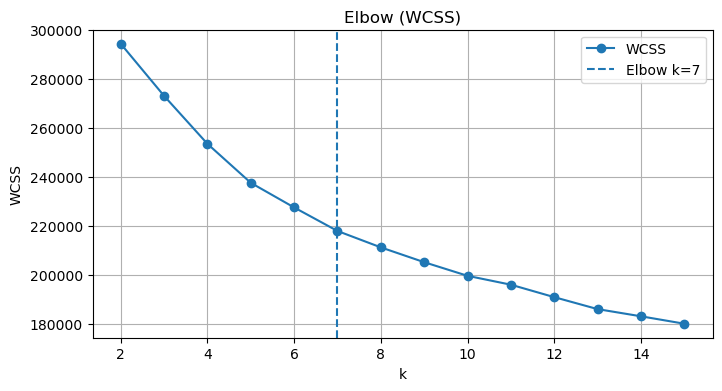

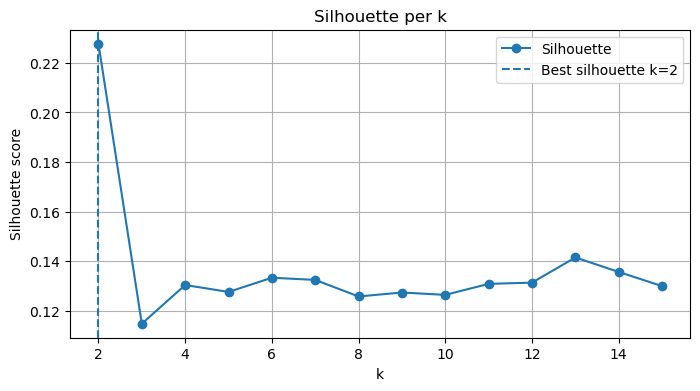

Elbow k: 7 | Best silhouette k: 2 | Selected k_opt: 7


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator


# 2) Define feature columns (already scaled), Exclude metadata/labels/non-features

exclude = {"SMILES", "MP", "Type", "MW_label"}
num_cols = df_highMW.select_dtypes(include=[np.number]).columns
feature_cols = [c for c in num_cols if c not in exclude]

X_scaled = df_highMW[feature_cols].to_numpy(dtype=np.float32)

print("X_scaled shape:", X_scaled.shape)
print("Num features:", len(feature_cols))


# 3) Find optimal k

random_state = 0
k_opt = find_optimal_clusters(X_scaled=X_scaled, max_k=15, random_state=random_state, plot=True)

if k_opt is None:
    k_opt = 3
    print("No clear elbow/silhouette; defaulting to k=3.")


# 4) Fit final kmeans + assign clusters

final_kmeans = KMeans(
    n_clusters=int(k_opt),
    init="k-means++",
    n_init=10,
    random_state=random_state
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

assert len(cluster_labels) == len(df_highMW), "Cluster labels length != df rows (mismatch)."

df_clustered = df_highMW.copy()
df_clustered["Structure_Cluster"] = cluster_labels


In [7]:
df_clustered.head()

,SMILES,MP,Type,MW_label,RDKit_fr_NH1,RDKit_VSA_EState7,RDKit_EState_VSA8,RDKit_VSA_EState9,RDKit_SlogP_VSA4,RDKit_fr_pyridine,...,RDKit_FpDensityMorgan2,RDKit_SPS,RDKit_fr_ester,RDKit_VSA_EState1,RDKit_SMR_VSA6,RDKit_fr_bicyclic,RDKit_SMR_VSA5,RDKit_NumAtomStereoCenters,RDKit_PEOE_VSA9,Structure_Cluster
10,O=CC1(C)C(O)CCC2(C1CCC1(C2CC=C2C1(C)CCC1(C2CC(...,275.0,Train,1,-0.463609,2.094291,1.448913,-0.154896,4.455912,-0.266204,...,-0.247127,3.872900,-0.333509,-0.445016,-0.677532,5.120594,3.296752,4.368582,0.973310,6
11,CCCCCCCCCCCCCCCCCCOCC(CO)O,70.5,Train,1,-0.463609,3.904946,-0.318254,-0.154896,-0.658120,-0.266204,...,-1.678766,-0.250870,-0.333509,-0.166897,1.507595,-0.462140,3.435871,0.161796,0.547773,2
15,O=C1CN(C(=O)N1)/N=C/c1ccc(o1)c1ccc(cc1)[N+](=O...,279.5,Train,1,1.305228,-0.060135,-0.135396,-0.154896,0.371362,-0.266204,...,0.538347,-0.061422,-0.333509,-0.154605,0.043995,-0.462140,-0.686903,-0.364053,0.310325,3
21,[O-][N+](=O)c1ccc(cc1)/C=C/C1OC(=O)c2c(C1)cccc2,181.0,Train,1,-0.463609,0.456818,-0.680559,-0.154896,0.371362,-0.266204,...,0.323049,0.195190,1.449116,-0.163374,-0.677532,0.335393,-0.240838,0.161796,0.235843,1
22,CCCCCCCCCCCCC#CC#CCCCCCCCCC(=O)O,64.0,Train,1,-0.463609,4.132386,0.920964,-0.154896,1.752317,-0.266204,...,-1.764613,-0.516758,-0.333509,-0.445016,-0.677532,-0.462140,3.904506,-0.364053,-0.963694,2


In [8]:
TARGET_COL = "MP"

exclude = {"SMILES", TARGET_COL, "Type", "MW_label", "Structure_Cluster"}
num_cols = df_clustered.select_dtypes(include=[np.number]).columns
feature_cols = [c for c in num_cols if c not in exclude]

X = df_clustered[feature_cols].to_numpy(np.float32) 
y = df_clustered[TARGET_COL].to_numpy(np.float32)
y_strat = df_clustered["Structure_Cluster"].astype(str).to_numpy()

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=10)
folds = [(tr, va) for tr, va in skf.split(X, y_strat)]

print("Total samples:", len(X))
print("Num features:", X.shape[1])
print("Num folds:", len(folds))
print()

for i, (tr_idx, va_idx) in enumerate(folds):
    print(
        f"Fold {i:2d} | "
        f"Train: {len(tr_idx):4d} | "
        f"Val: {len(va_idx):4d}"
    )


Total samples: 3098
Num features: 72
Num folds: 10

Fold  0 | Train: 2788 | Val:  310
Fold  1 | Train: 2788 | Val:  310
Fold  2 | Train: 2788 | Val:  310
Fold  3 | Train: 2788 | Val:  310
Fold  4 | Train: 2788 | Val:  310
Fold  5 | Train: 2788 | Val:  310
Fold  6 | Train: 2788 | Val:  310
Fold  7 | Train: 2788 | Val:  310
Fold  8 | Train: 2789 | Val:  309
Fold  9 | Train: 2789 | Val:  309


In [9]:
from pathlib import Path
import json, joblib, numpy as np, pandas as pd, torch, optuna

# Must be a CNN baseline checkpoint, not an MLP checkpoint
BASELINE_CKPT = Path("artifacts_CNN/CNN_best_LowMW_RDKit_60(split)_MW(label)_70(threshold)/general_best_fold_6.pt")

N_TRIALS = 10

OUT_ROOT = Path("artifacts_CNN/TL_MW_RDKit_60(split)_MW(label)_70(threshold)")
OUT_ROOT.mkdir(parents=True, exist_ok=True)


def run_one_scenario(tag, freeze_vec, freeze_level):
    print(f"\n=== Scenario: {tag} | freeze={freeze_vec} (level={freeze_level}) ===")
    SCEN_OUT = OUT_ROOT / tag
    (SCEN_OUT / "trials").mkdir(parents=True, exist_ok=True)

    def objective_tl_fixed(trial):
        learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
        weight_decay  = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
        batch_size    = trial.suggest_categorical("batch_size", [16, 32, 64])
        dropout_rate  = trial.suggest_float("dropout_rate", 0.2, 0.5)

        trial_dir = SCEN_OUT / "trials" / f"trial_{trial.number:04d}"
        trial_dir.mkdir(parents=True, exist_ok=True)

        fold_metrics, rmses = [], []
        for fold_idx, (tr_idx, va_idx) in enumerate(folds):
            X_tr, y_tr = X[tr_idx], y[tr_idx]
            X_va, y_va = X[va_idx], y[va_idx]

            rmse, r2, q2, model, *_ = evaluate_fold_TL(
                trial=trial,
                fold_idx=fold_idx,
                X_train_scaled=X_tr, y_train=y_tr,
                X_val_scaled=X_va,   y_val=y_va,
                hidden_layers=None,                # placeholder only; CNN does not use this
                dropout_rate=dropout_rate,
                learning_rate=learning_rate,
                weight_decay=weight_decay,
                batch_size=batch_size,
                freeze_level=freeze_level,
                baseline_ckpt=BASELINE_CKPT,
                max_epochs=10**6,
                patience=30,
                min_delta=0.0,
                save_checkpoints=False
            )

            ckpt_path = trial_dir / f"fold_{fold_idx}_best.pth"
            torch.save(model.state_dict(), ckpt_path)

            fold_metrics.append({
                "fold": fold_idx,
                "rmse": float(rmse),
                "r2": float(r2),
                "q2": float(q2),
                "checkpoint": str(ckpt_path)
            })
            rmses.append(rmse)

        summary = {
            "scenario": tag,
            "freeze_vector": freeze_vec,
            "freeze_level": freeze_level,
            "trial_number": trial.number,
            "model_type": "CNNRegressor",
            "params": {
                "learning_rate": learning_rate,
                "weight_decay": weight_decay,
                "batch_size": batch_size,
                "dropout_rate": dropout_rate
            },
            "avg_rmse": float(np.mean(rmses)),
            "folds": fold_metrics
        }

        with open(trial_dir / "summary.json", "w") as f:
            json.dump(summary, f, indent=2)

        return float(np.mean(rmses))

    # HPO
    study = optuna.create_study(direction="minimize")
    study.optimize(objective_tl_fixed, n_trials=N_TRIALS, gc_after_trial=True)

    joblib.dump(study, SCEN_OUT / "study.joblib")
    study.trials_dataframe().to_csv(SCEN_OUT / "trials.csv", index=False)

    with open(SCEN_OUT / "best_params.json", "w") as f:
        json.dump(study.best_params, f, indent=2)

    with open(SCEN_OUT / "best_value.txt", "w") as f:
        f.write(f"{study.best_value:.6f}\n")

    print(f"[{tag}] Best avg RMSE: {study.best_value:.4f}")
    print(f"[{tag}] Best params: {study.best_params}")

    # Final per-fold retrain with best params
    best = study.best_params
    FINAL_DIR = SCEN_OUT / "final_fold_models"
    FINAL_DIR.mkdir(parents=True, exist_ok=True)

    rows = []
    for fold_idx, (tr_idx, va_idx) in enumerate(folds):
        X_tr, y_tr = X[tr_idx], y[tr_idx]
        X_va, y_va = X[va_idx], y[va_idx]

        rmse, r2, q2, model, *_ = evaluate_fold_TL(
            trial=None,
            fold_idx=fold_idx,
            X_train_scaled=X_tr, y_train=y_tr,
            X_val_scaled=X_va,   y_val=y_va,
            hidden_layers=None,               # placeholder only
            dropout_rate=best["dropout_rate"],
            learning_rate=best["learning_rate"],
            weight_decay=best["weight_decay"],
            batch_size=best["batch_size"],
            freeze_level=freeze_level,
            baseline_ckpt=BASELINE_CKPT,
            max_epochs=10**6,
            patience=30,
            min_delta=0.0,
            save_checkpoints=False
        )

        ckpt = FINAL_DIR / f"fold_{fold_idx}_best.pth"
        torch.save(model.state_dict(), ckpt)

        rows.append({
            "fold": fold_idx,
            "rmse": float(rmse),
            "r2": float(r2),
            "q2": float(q2),
            "checkpoint": str(ckpt)
        })

    cv_df = pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)
    cv_df.to_csv(SCEN_OUT / "cv_final_metrics.csv", index=False)

    best_row = cv_df.iloc[0]
    manifest = {
        "scenario": tag,
        "freeze_vector": freeze_vec,
        "freeze_level": freeze_level,
        "model_type": "CNNRegressor",
        "best_fold": int(best_row["fold"]),
        "checkpoint": best_row["checkpoint"],
        "best_params": best
    }

    with open(SCEN_OUT / "manifest.json", "w") as f:
        json.dump(manifest, f, indent=2)

    print(f"[{tag}] Best fold: {manifest['best_fold']} → {manifest['checkpoint']}")
    return study, cv_df, manifest


# ---------- RUN ALL THREE ----------
SCENARIOS = [
    ("no_freeze",          [0, 0, 0], 0),
    ("freeze_conv1",       [1, 0, 0], 1),
    ("freeze_conv1_conv2", [1, 1, 0], 2),
]

results = {}
for tag, vec, lvl in SCENARIOS:
    study, cv_df, manifest = run_one_scenario(tag, vec, lvl)
    results[tag] = {"best": study.best_value, "manifest": manifest}

print("\nSummary:", json.dumps(results, indent=2))

[I 2026-03-09 13:31:32,656] A new study created in memory with name: no-name-16c0c9ef-3eb6-4742-a30d-f93999631935



=== Scenario: no_freeze | freeze=[0, 0, 0] (level=0) ===
Fold 0: CNN TL on cpu | freeze=0 | lr=0.000611267
Freeze Level 0: all layers trainable


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW_models/CNN_model_helper.py:416: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(baseline_ckpt, map_loc

[Fold 0] Epoch    1 | Train 64.1449 | Val 52.7279 | ES 0/30
[Fold 0] Early stopping at epoch 50 (best Val Loss: 44.0463)
Fold 1: CNN TL on cpu | freeze=0 | lr=0.000611267
Freeze Level 0: all layers trainable


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW_models/CNN_model_helper.py:416: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(baseline_ckpt, map_loc

...

[Fold 7] Epoch    1 | Train 62.7145 | Val 53.5005 | ES 0/30
[Fold 7] Epoch   50 | Train 47.4994 | Val 42.4903 | ES 0/30
[Fold 7] Epoch  100 | Train 44.2824 | Val 43.3866 | ES 8/30
[Fold 7] Epoch  150 | Train 41.2187 | Val 40.1872 | ES 4/30
[Fold 7] Early stopping at epoch 176 (best Val Loss: 39.7204)
Fold 8: CNN TL on cpu | freeze=2 | lr=0.000889114
Freeze Level 2: freezing 2 CNN block(s)


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW_models/CNN_model_helper.py:416: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(baseline_ckpt, map_loc

[Fold 8] Epoch    1 | Train 62.7564 | Val 56.9494 | ES 0/30
[Fold 8] Epoch   50 | Train 46.4301 | Val 49.0996 | ES 4/30
[Fold 8] Epoch  100 | Train 43.9361 | Val 47.4330 | ES 17/30
[Fold 8] Early stopping at epoch 113 (best Val Loss: 47.4265)
Fold 9: CNN TL on cpu | freeze=2 | lr=0.000889114
Freeze Level 2: freezing 2 CNN block(s)


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW_models/CNN_model_helper.py:416: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(baseline_ckpt, map_loc

[Fold 9] Epoch    1 | Train 63.5335 | Val 48.8643 | ES 0/30
[Fold 9] Epoch   50 | Train 46.6711 | Val 43.1328 | ES 7/30
[Fold 9] Epoch  100 | Train 43.7817 | Val 42.4618 | ES 11/30
[Fold 9] Early stopping at epoch 119 (best Val Loss: 42.3102)
[freeze_conv1_conv2] Best fold: 7 → artifacts_CNN/TL_MW_RDKit_60(split)_MW(label)_70(threshold)/freeze_conv1_conv2/final_fold_models/fold_7_best.pth

Summary: {
  "no_freeze": {
    "best": 44.41084518432617,
    "manifest": {
      "scenario": "no_freeze",
      "freeze_vector": [
        0,
        0,
        0
      ],
      "freeze_level": 0,
      "model_type": "CNNRegressor",
      "best_fold": 9,
      "checkpoint": "artifacts_CNN/TL_MW_RDKit_60(split)_MW(label)_70(threshold)/no_freeze/final_fold_models/fold_9_best.pth",
      "best_params": {
        "learning_rate": 0.0007696620262036246,
        "weight_decay": 7.562562951472516e-06,
        "batch_size": 16,
        "dropout_rate": 0.4744293543241538
      }
    }
  },
  "freeze_conv1":

In [14]:
from CNN_model import CNNRegressor
import torch
import pandas as pd
from pathlib import Path
import json

def load_best_models_for_scenarios(
    root_dir="artifacts_CNN/TL_MW_RDKit_60(split)_MW(label)_70(threshold)",
    scenarios=("no_freeze", "freeze_conv1", "freeze_conv1_conv2"),
):
    root_dir = Path(root_dir)
    models = {}
    manifests = {}

    for tag in scenarios:
        manifest_path = root_dir / tag / "manifest.json"
        cv_metrics_path = root_dir / tag / "cv_final_metrics.csv"

        # Load manifest
        with open(manifest_path, "r") as f:
            manifest = json.load(f)
        manifests[tag] = manifest

        # Load best RMSE from cv_final_metrics.csv
        cv_df = pd.read_csv(cv_metrics_path)
        best_row = cv_df.sort_values("rmse").iloc[0]
        best_rmse = float(best_row["rmse"])

        # Load checkpoint
        ckpt_path = Path(best_row["checkpoint"]).resolve()
        state = torch.load(ckpt_path, map_location="cpu")

        dropout_rate = manifest["best_params"]["dropout_rate"]

        # Build CNN model
        model = CNNRegressor(
            dropout_rate=dropout_rate
        )

        model.load_state_dict(state)
        model.eval()

        models[tag] = model

        print(f"Loaded model for scenario '{tag}'")
        print(f"  └─ Best fold checkpoint: {ckpt_path}")
        print(f"  └─ Best RMSE: {best_rmse:.4f}\n")

    return models, manifests

models, manifests = load_best_models_for_scenarios(
    root_dir="artifacts_CNN/TL_MW_RDKit_60(split)_MW(label)_70(threshold)",
    scenarios=["no_freeze", "freeze_conv1", "freeze_conv1_conv2"]
)

Loaded model for scenario 'no_freeze'
  └─ Best fold checkpoint: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW_models/artifacts_CNN/TL_MW_RDKit_60(split)_MW(label)_70(threshold)/no_freeze/final_fold_models/fold_9_best.pth
  └─ Best RMSE: 40.5357

Loaded model for scenario 'freeze_conv1'
  └─ Best fold checkpoint: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW_models/artifacts_CNN/TL_MW_RDKit_60(split)_MW(label)_70(threshold)/freeze_conv1/final_fold_models/fold_7_best.pth
  └─ Best RMSE: 40.5074

Loaded model for scenario 'freeze_conv1_conv2'
  └─ Best fold checkpoint: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW_models/artifacts_CNN/TL_MW_RDKit_60(split)_MW(label)_70(threshold)/freeze_conv1_conv2/final_fold_models/fold_7_best.pth
  └─ Best RMSE: 39.9147



/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_67681/3947318800.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt_path, map_location="

TEST EVALUATION

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import joblib

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from NN_model import ImprovedNN  # adjust if needed

In [2]:
df = pd.read_parquet("../MW/artifacts/final_dataset_RDKit_60_MW_scaled.parquet")
df.head()

,SMILES,MP,Type,MW_label,RDKit_fr_NH1,RDKit_VSA_EState9,RDKit_SlogP_VSA4,RDKit_fr_unbrch_alkane,RDKit_fr_NH0,RDKit_NumAliphaticRings,...,RDKit_SMR_VSA10,RDKit_RingCount,RDKit_FpDensityMorgan2,RDKit_fr_ester,RDKit_VSA_EState1,RDKit_fr_bicyclic,RDKit_SMR_VSA5,RDKit_NumAtomStereoCenters,RDKit_SMR_VSA1,RDKit_PEOE_VSA9
0,CCOC(=O)/C(=C/c1ccc(o1)c1ccc(cc1)Cl)/C#N,140.0,Train,1,-0.463349,-0.150724,0.501978,-0.175089,0.199077,-0.497490,...,0.439775,0.104041,0.735690,1.519681,0.112624,-0.453481,-0.438297,-0.360924,0.237181,-0.207736
1,Brc1ccc2c(c1)c(=O)[nH]cc2,249.0,Train,0,1.259950,-0.150724,-0.661798,-0.175089,-0.674327,-0.497490,...,0.650404,0.104041,0.817902,-0.328623,-0.405680,0.348533,-0.691195,-0.360924,-1.118907,-0.952135
2,Nc1c(cnn1CCO)C(=O)N,239.0,Train,0,-0.463349,-0.150724,-0.661798,-0.175089,1.072481,-0.497490,...,-0.381838,-0.662138,1.585215,-0.328623,-0.383935,-0.453481,-0.452140,-0.360924,-0.156318,1.227865
3,OC(C=O)CO,145.0,Train,0,-0.463349,-0.150724,-0.661798,-0.175089,-0.674327,-0.497490,...,-0.756687,-1.428316,1.393386,-0.328623,-0.456272,-0.453481,-0.468240,0.182910,0.340142,-0.207736
4,CCOC(=O)C12C(c3cc(Br)ccc3O[P@@]2(=O)OCC)C2(C1c...,273.0,Train,1,-0.463349,-6.046404,-0.661798,-0.175089,-0.674327,2.339192,...,2.875673,2.402576,-1.445669,3.367986,3.181505,5.962631,1.129382,2.902081,3.381234,2.025463


In [3]:
df_test = df[
    (df["Type"] == "Test")
].copy()

print("Shape:", df_test.shape)

Shape: (6888, 69)


In [ ]:
##################---------------------------- NO FREEZE TEST EVALUATION ----------------------------#######################

from pathlib import Path
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from CNN_model import CNNRegressor

# PATHS
BASE = Path.cwd()
CKPT_PTH = BASE / "artifacts_CNN/TL_MW_RDKit_60(split)_MW(label)_70(threshold)/no_freeze/final_fold_models/fold_0_best.pth"

OUT_PRED_CSV = BASE / "artifacts_CNN/test_TL_MW_predictions_no_freeze_RDKit_60(split)_MW(label)_70(threshold).csv"

# MODEL PARAMETERS
DROPOUT_RATE = 0.00019083864094777392   # use the same dropout_rate used for that checkpoint

NON_FEATURES = ["SMILES", "MP", "Type", "MW_label"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]

X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])

# Recreate model + load checkpoint
device = torch.device("cpu")

model = CNNRegressor(
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()

# Predict
X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).cpu().numpy().astype(float)

# Evaluate
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")

# Save predictions
out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "MW_label": df_test["MW_label"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")

rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_lowMW = out_df[out_df["MW_label"] == 0]
rmse_lowMW = np.sqrt(np.mean(df_lowMW["error"] ** 2))
print(f"RMSE (lowMW): {rmse_lowMW:.3f}")

df_highMW = out_df[out_df["MW_label"] == 1]
rmse_highMW = np.sqrt(np.mean(df_highMW["error"] ** 2))
print(f"RMSE (highMW): {rmse_highMW:.3f}")

In [22]:
##################---------------------------- NO FREEZE TEST EVALUATION ----------------------------#######################

# PATHS

BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts_threshold/TL_MW_RDKit_60(split)_MW(label)_60(threshold)/no_freeze/final_fold_models/fold_0_best.pth"

OUT_PRED_CSV = BASE / "artifacts_threshold/test_TL_MW_predictions_no_freeze_RDKit_60(split)_MW(label)_60(threshold).csv"

# MODEL PARAMETERS (must match checkpoint architecture)

HIDDEN_LAYERS = [256, 128, 64]
DROPOUT_RATE =0.00019083864094777392   # must match best params used for that checkpoint


NON_FEATURES = ["SMILES", "MP", "Type", "MW_label"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]


X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])


# Recreate model + load checkpoint

device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()


# Predict

X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)


# Evaluate

rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")


# Save predictions

out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "MW_label": df_test["MW_label"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")


rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_lowMW = out_df[out_df["MW_label"] == 0]
rmse_lowMW = np.sqrt(np.mean(df_lowMW["error"] ** 2))
print(f"RMSE (lowMW): {rmse_lowMW:.3f}")

df_highMW = out_df[out_df["MW_label"] == 1]
rmse_highMW = np.sqrt(np.mean(df_highMW["error"] ** 2))
print(f"RMSE (highMW): {rmse_highMW:.3f}")

Test rows: 6888
Features: 65


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_87493/3229049017.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d

RuntimeError: Error(s) in loading state_dict for ImprovedNN:
	size mismatch for network.0.weight: copying a param with shape torch.Size([256, 140]) from checkpoint, the shape in current model is torch.Size([256, 65]).

In [ ]:
##################---------------------------- FC1 TEST EVALUATION ----------------------------#######################

# PATHS

BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_MW_RDKit_60/freeze_fc1/final_fold_models/fold_5_best.pth"

OUT_PRED_CSV = BASE / "artifacts/test_TL_MW_predictions_freeze_fc1_RDKit_60.csv"

# MODEL PARAMETERS (must match checkpoint architecture)

HIDDEN_LAYERS = [224, 112, 56]
DROPOUT_RATE = 0.2871887506335837   # must match best params used for that checkpoint


NON_FEATURES = ["SMILES", "MP", "Type", "MW_label", "Structure_Cluster"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]


X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])


# Recreate model + load checkpoint

device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()


# Predict

X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)


# Evaluate

rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")


# Save predictions

out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "MW_label": df_test["MW_label"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")


rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_lowMW = out_df[out_df["MW_label"] == 0]
rmse_lowMW = np.sqrt(np.mean(df_lowMW["error"] ** 2))
print(f"RMSE (lowMW): {rmse_lowMW:.3f}")

df_highMW = out_df[out_df["MW_label"] == 1]
rmse_highMW = np.sqrt(np.mean(df_highMW["error"] ** 2))
print(f"RMSE (highMW): {rmse_highMW:.3f}")

Test rows: 6888
Features: 65

=== TEST METRICS ===
RMSE: 41.6877
MAE : 32.1589
R^2 : 0.6544

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW/artifacts/test_TL_MW_predictions_freeze_fc1_RDKit_60.csv
Total RMSE (all): 41.688
RMSE (lowMW): 42.036
RMSE (highMW): 40.697


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_17146/3941208020.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d

In [22]:
##################---------------------------- NO FREEZE TEST EVALUATION ----------------------------#######################

# PATHS

BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_MW_RDKit_60/freeze_fc1_fc2/final_fold_models/fold_5_best.pth"

OUT_PRED_CSV = BASE / "artifacts/test_TL_MW_predictions_freeze_fc1_fc2_RDKit_60.csv"

# MODEL PARAMETERS (must match checkpoint architecture)

HIDDEN_LAYERS = [224, 112, 56]
DROPOUT_RATE = 0.2871887506335837   # must match best params used for that checkpoint


NON_FEATURES = ["SMILES", "MP", "Type", "MW_label", "Structure_Cluster"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]


X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])


# Recreate model + load checkpoint

device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()


# Predict

X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)


# Evaluate

rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")


# Save predictions

out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "MW_label": df_test["MW_label"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")


rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_lowMW = out_df[out_df["MW_label"] == 0]
rmse_lowMW = np.sqrt(np.mean(df_lowMW["error"] ** 2))
print(f"RMSE (lowMW): {rmse_lowMW:.3f}")

df_highMW = out_df[out_df["MW_label"] == 1]
rmse_highMW = np.sqrt(np.mean(df_highMW["error"] ** 2))
print(f"RMSE (highMW): {rmse_highMW:.3f}")

Test rows: 6888
Features: 65

=== TEST METRICS ===
RMSE: 44.4402
MAE : 34.4979
R^2 : 0.6072

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW/artifacts/test_TL_MW_predictions_freeze_fc1_fc2_RDKit_60.csv
Total RMSE (all): 44.440
RMSE (lowMW): 44.445
RMSE (highMW): 44.426


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_17146/2078923357.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d